In [1]:
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import xgboost, lightgbm
import lightgbm as lgb


In [2]:
path = "../data/final/all_reviews_full_with_genres.parquet"
dataset = ds.dataset(path, format="parquet")


df = (
    dataset
    .scanner(columns=[
        "appid", "review", "voted_up",
        "author_num_games_owned",
        "author_num_reviews",
        "author_playtime_forever",
        "author_playtime_last_two_weeks",
        "author_playtime_at_review",
        "language",
        "steam_purchase",
        "received_for_free",
        "written_during_early_access",
        "timestamp_created"
    ])
    .head(500_000)
    .to_pandas()
)
# Cap per app
CAP_PER_APP = 500
df = (
    df.groupby("appid", group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), CAP_PER_APP), random_state=42))
      .reset_index(drop=True)
)
df["review"] = df["review"].fillna("").astype(str)
df["voted_up"] = df["voted_up"].astype(int)
# Time features
df["timestamp_created"] = pd.to_datetime(df["timestamp_created"], unit="s", errors="coerce")
df["created_year"] = df["timestamp_created"].dt.year
df["created_month"] = df["timestamp_created"].dt.month
df["created_dow"] = df["timestamp_created"].dt.dayofweek
df["created_hour"] = df["timestamp_created"].dt.hour

# Log1p playtime features
for c in ["author_playtime_forever", "author_playtime_last_two_weeks", "author_playtime_at_review"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[f"log1p_{c}"] = np.log1p(df[c])

num_cols = [
    "author_num_games_owned",
    "author_num_reviews",
    "log1p_author_playtime_forever",
    "log1p_author_playtime_last_two_weeks",
    "log1p_author_playtime_at_review",
    "created_year", "created_month", "created_dow", "created_hour"
]
cat_cols = [
    "language",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access"
]

text_col = "review"

X = df[[text_col] + num_cols + cat_cols].copy()
y = df["voted_up"].values

# Make categoricals safe for OneHotEncoder (no NaNs, consistent type)
X[cat_cols] = X[cat_cols].fillna("missing").astype(str)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)




tfidf = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True,
    strip_accents="unicode"
)

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median"))
])

categorical_pipe = OneHotEncoder(handle_unknown="ignore")

def make_preprocess(kind):
    transformers = []
    if kind in ("text_only", "text_plus_meta"):
        transformers.append(("tfidf", tfidf, text_col))
    if kind in ("meta_only", "text_plus_meta"):
        transformers.append(("num", numeric_pipe, num_cols))
        transformers.append(("cat", categorical_pipe, cat_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)


from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    average_precision_score, confusion_matrix,
    precision_recall_fscore_support
)

def fit_eval(kind: str):
    preprocess = make_preprocess(kind)

    clf = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=2000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)  # fixed threshold

    # Confusion matrix
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Per-class precision/recall (class 0 = negative, class 1 = positive)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, pred, labels=[0, 1], zero_division=0
    )
    neg_prec, pos_prec = prec
    neg_rec,  pos_rec  = rec

    return {
        "Setup": kind,
        "ROC_AUC": roc_auc_score(y_test, proba),
        "PR_AUC": average_precision_score(y_test, proba),  # aka AP for positive class
        "F1_pos": f1_score(y_test, pred),                  # sklearn default = positive class
        "Accuracy": accuracy_score(y_test, pred),
        "Neg_Precision": neg_prec,
        "Neg_Recall": neg_rec,
        "Pos_Precision": pos_prec,
        "Pos_Recall": pos_rec,
        "PosRate_Test": float(np.mean(y_test)),
        "_cm": cm,  # keep for printing below
    }

# Run all 3
setups = ["text_only", "meta_only", "text_plus_meta"]
results = [fit_eval(k) for k in setups]

# Results table 
table = pd.DataFrame([{k: v for k, v in r.items() if k != "_cm"} for r in results])
table = table.sort_values("ROC_AUC", ascending=False)

pd.set_option("display.precision", 4)
print("\n=== Results (fixed threshold = 0.5) ===")
print(table.to_string(index=False))

# Confusion matrices
print("\n=== Confusion Matrices (rows=true [0,1], cols=pred [0,1]) ===")
for r in sorted(results, key=lambda d: d["ROC_AUC"], reverse=True):
    cm = r["_cm"]
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {r['Setup']} ---")
    print(cm)
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")



/tmp/ipykernel_735/4224605317.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), CAP_PER_APP), random_state=42))


[LightGBM] [Info] Number of positive: 47011, number of negative: 11917
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.172592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 585220
[LightGBM] [Info] Number of data points in the train set: 58928, number of used features: 19691
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 47011, number of negative: 11917
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 58928, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [3]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

oof = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print("Fold:", fold+1)

    X_tr, X_va = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_va = y[tr_idx], y[val_idx]

    pipe = Pipeline([
        ("prep", make_preprocess("text_plus_meta")),
        ("clf", lgb.LGBMClassifier(
            objective="binary",
            n_estimators=2000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipe.fit(X_tr, y_tr)

    oof[val_idx] = pipe.predict_proba(X_va)[:,1]

print("\nCV ROC-AUC:", roc_auc_score(y, oof))



Fold: 1
[LightGBM] [Info] Number of positive: 39176, number of negative: 9931
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.860296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 489540
[LightGBM] [Info] Number of data points in the train set: 49107, number of used features: 16696
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Fold: 2
[LightGBM] [Info] Number of positive: 39176, number of negative: 9931
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.836620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 480191
[LightGBM] [Info] Number of data points in the train set: 49107, number of used features: 16354
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from scor

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

def cv_validate_light(kind, X, y, n_splits=3, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof = np.zeros(len(y))
    fold_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\nFold: {fold}")

        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        pipe = Pipeline([
            ("prep", make_preprocess(kind)),
            ("clf", lgb.LGBMClassifier(
                objective="binary",
                n_estimators=2000,
                class_weight="balanced",
                random_state=random_state,
                n_jobs=-1
            ))
        ])

        pipe.fit(X_tr, y_tr)

        proba_val = pipe.predict_proba(X_val)[:, 1]
        oof[val_idx] = proba_val

        fold_auc = roc_auc_score(y_val, proba_val)
        fold_ap = average_precision_score(y_val, proba_val)

        fold_rows.append({
            "fold": fold,
            "val_roc_auc": fold_auc,
            "val_pr_auc": fold_ap
        })

    cv_auc = roc_auc_score(y, oof)
    cv_ap = average_precision_score(y, oof)

    return {
        "Setup": kind,
        "CV_ROC_AUC": cv_auc,
        "CV_PR_AUC": cv_ap,
        "folds": pd.DataFrame(fold_rows)
    }

setups = ["text_only", "meta_only", "text_plus_meta"]
out = [cv_validate_light(k, X, y, n_splits=3) for k in setups]
cv_table = (
    pd.DataFrame([
        {kk: vv for kk, vv in r.items() if kk != "folds"}
        for r in out
    ])
    .sort_values("CV_ROC_AUC", ascending=False)
)

pd.set_option("display.precision", 4)
print("\n=== Cross-Validation Results ===")
print(cv_table.to_string(index=False))
for r in out:
    print("\n============================")
    print("Setup:", r["Setup"])
    print(r["folds"].to_string(index=False))



Fold: 1
[LightGBM] [Info] Number of positive: 39176, number of negative: 9931
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.846767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 488145
[LightGBM] [Info] Number of data points in the train set: 49107, number of used features: 16655
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

Fold: 2
[LightGBM] [Info] Number of positive: 39176, number of negative: 9931
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.830745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 478796
[LightGBM] [Info] Number of data points in the train set: 49107, number of used features

We conducted 3-fold stratified cross-validation comparing text-only, metadata-only, and combined feature pipelines. The text+metadata LightGBM model achieved the strongest performance (CV ROC-AUC = 0.860), outperforming text-only (0.813) and metadata-only (0.708). Performance was highly stable across folds, indicating strong generalization and minimal variance. Results demonstrate that while review text is the primary predictive signal, behavioral and contextual metadata provide meaningful incremental value.

In [6]:
# Train final model on ALL data using best setup
final_pipe = Pipeline([
    ("prep", make_preprocess("text_plus_meta")),
    ("clf", lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

final_pipe.fit(X, y)

# Get feature names
feature_names = final_pipe.named_steps["prep"].get_feature_names_out()

# Get importance
importances = final_pipe.named_steps["clf"].feature_importances_

feat_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

feat_df.head(20)


[LightGBM] [Info] Number of positive: 58764, number of negative: 14897
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.667623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 737839
[LightGBM] [Info] Number of data points in the train set: 73661, number of used features: 24378
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,feature,importance
200002,num__log1p_author_playtime_forever,730
200001,num__author_num_reviews,588
200004,num__log1p_author_playtime_at_review,472
200000,num__author_num_games_owned,393
200008,num__created_hour,386
200006,num__created_month,338
200005,num__created_year,251
200007,num__created_dow,193
97970,tfidf__not,122
96993,tfidf__no,115


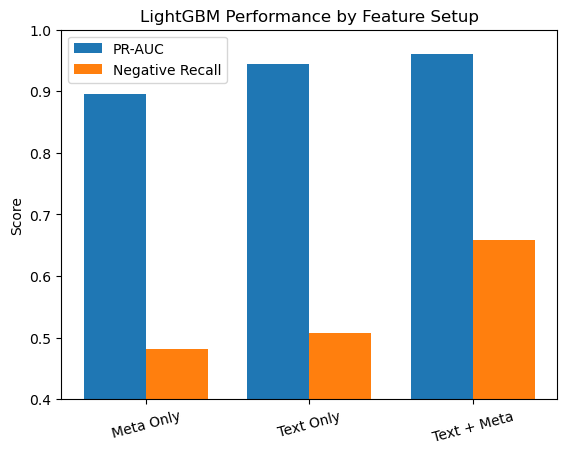

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_plot = pd.DataFrame({
    "Setup": ["Meta Only", "Text Only", "Text + Meta"],
    "PR_AUC": [0.8952, 0.9437, 0.9605],
    "Neg_Recall": [0.4822, 0.5067, 0.6584]
})

x = np.arange(len(df_plot))
w = 0.38

plt.figure()
plt.bar(x - w/2, df_plot["PR_AUC"], width=w, label="PR-AUC")
plt.bar(x + w/2, df_plot["Neg_Recall"], width=w, label="Negative Recall")

plt.title("LightGBM Performance by Feature Setup")
plt.ylabel("Score")
plt.xticks(x, df_plot["Setup"], rotation=15)
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()